# Этап 2

## Задача

### Построение прогноза температуры с использованием рекуррентных и сверточных нейронных сетей

Целью данного этапа лабораторной работы является создание нейронной сети, реализующей прогноз температуры по набору данных Jena Climate.

Пошаговая реализация поставленной цели включает:
1. Загрузку набора данных Jena Climate;
2. Разделение данных на обучающий и тестовый наборы;
3. Создание генератора данных, выбрав базу данных за 10 дней, задержку в 1 день, 1 значение в час и размер пакета из варианта;
4. Подготовку данных для передачи в нейронную сеть;
5. Выполнить конструирование сети, создание сети рекуррентных слоев заданного типа в соответствии с вариантом;
6. Настройку оптимизатора с выбором функции потерь и метрики качества. Число эпох принять от 30 до 60;
7. Проведение проверки решения, выделяя контрольное множество;
8. Вывод графиков функции потерь и точности;
9. Использование обученной сети для предсказания на новых данных;
10. Сопоставление полученных результатов с сетью, первый блок которого является одномерной сверточной сетью (три сверточных слоя), а затем идет второй блок, указанный в варианте.

## Вариант

### №2
* Количество рекуррентных слоев: **2**
* Количество нейронов на слое: **32-64**
* Рекуррентный слой: **GRU**
* Прореживание: **0.2**

## Решение

### Шаг 0: подготовка

#### Импорт библиотек

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import random

In [15]:
sequence_length, delay, batch_size = 1440, 144, 64

### Шаг 1: загрузка и предобработка данных

In [16]:
data_path = 'jena_climate_2009_2016.csv'
data = pd.read_csv(data_path)
data = data[:300000]

### Шаг 2: разделение данных на тренировочную, валидационную и тестовую выборку

In [17]:
train_size = int(0.6 * len(data))
val_size = int(0.2 * len(data))
test_size = len(data) - train_size - val_size

train_data = data[:train_size]
val_data = data[train_size:train_size + val_size]
test_data = data[train_size + val_size:]

### Шаг 3: создание генераторов

In [18]:
def generator(data, lookback=sequence_length, delay=delay, batch_size=batch_size, step=1):
    while True:
        rows = np.random.randint(1, len(data) - lookback - delay - 1, size=batch_size)
        samples = np.zeros((batch_size, lookback // step, data.shape[-1]))
        targets = np.zeros((batch_size,))
        
        for i, row in enumerate(rows):
            indices = range(row, row + lookback, step)
            samples[i] = data.iloc[indices[0]:indices[-1]+1]
            targets[i] = data.iloc[row + lookback + delay - 1][1]
        
        yield samples, targets

### Шаг 4: подготовка данных

In [19]:
train_data = train_data.drop(columns=['Date Time'])
val_data = val_data.drop(columns=['Date Time'])
test_data = test_data.drop(columns=['Date Time'])

In [20]:
data_mean = train_data.mean()
data_std = train_data.std()
train_data = (train_data - data_mean) / data_std
val_data = (val_data - data_mean) / data_std
test_data = (test_data - data_mean) / data_std

In [21]:
train_generator = generator(train_data, sequence_length, delay, batch_size)
val_generator = generator(val_data, sequence_length, delay, batch_size)
test_generator = generator(test_data, sequence_length, delay, batch_size)

### Шаг 5: конструирование сети

In [22]:
model = Sequential([
    GRU(32, return_sequences=True, input_shape=(sequence_length, train_data.shape[-1])),
    Dropout(0.2),
    GRU(64),
    Dropout(0.2),
    Dense(1)
])

model.summary()

/Users/krukrukruzhka/github_projects/ML_magister/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 1440, 32)       │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1440, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,489 (91.75 KB)

 Trainable params: 23,489 (91.75 KB)

 Non-trainable params: 0 (0.00 B)

### Шаг 6: настройка сети

In [23]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae']
)

#### Обучение и валидация

In [24]:
epochs = 40
validation_steps=200

history = model.fit(
    train_generator,
    epochs=epochs,
    steps_per_epoch=10,
    validation_data=val_generator,
    validation_steps=validation_steps,
    verbose=1
)

Epoch 1/40


/var/folders/0g/zw0_s7w512zbvj6v01k842n00000gn/T/ipykernel_68109/1044423498.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  targets[i] = data.iloc[row + lookback + delay - 1][1]


10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - loss: 0.4171 - mae: 0.4171 - val_loss: 0.2969 - val_mae: 0.2969
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - loss: 0.3534 - mae: 0.3534 - val_loss: 0.2942 - val_mae: 0.2942
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - loss: 0.3350 - mae: 0.3350 - val_loss: 0.2967 - val_mae: 0.2967
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - loss: 0.3398 - mae: 0.3398 - val_loss: 0.2814 - val_mae: 0.2814
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - loss: 0.3408 - mae: 0.3408 - val_loss: 0.2840 - val_mae: 0.2840
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - loss: 0.3347 - mae: 0.3347 - val_loss: 0.2744 - val_mae: 0.2744
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - loss: 0.3256 - mae: 0.3256 - val_loss: 0.2795 - val_mae: 0.2795
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - loss: 0.3369 - mae: 0.3369 - val_loss: 0.2764 - val_mae: 0.2764
Epoch 9/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - loss: 0.3313 - mae: 0.3313 - va

### Шаг 8: вывод графиков потерь и точности

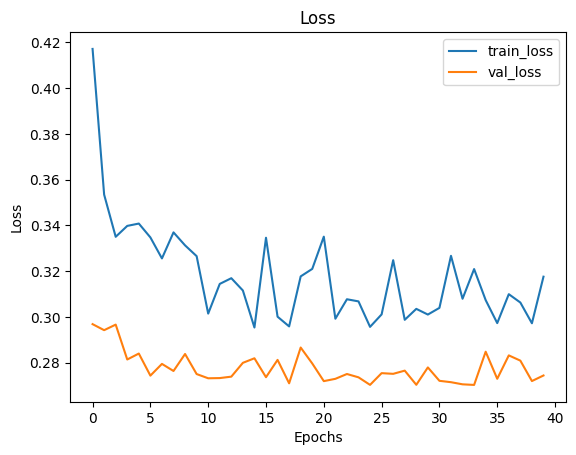

In [25]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Шаг 9: использование модели для предсказания

/var/folders/0g/zw0_s7w512zbvj6v01k842n00000gn/T/ipykernel_68109/1044423498.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  targets[i] = data.iloc[row + lookback + delay - 1][1]
/var/folders/0g/zw0_s7w512zbvj6v01k842n00000gn/T/ipykernel_68109/1442517413.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predictions = [x * data_std[1] + data_mean[1] for x in predictions]
/var/folders/0g/zw0_s7w512zbvj6v01k842n00000gn/T/ipykernel_68109/1442517413.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with D

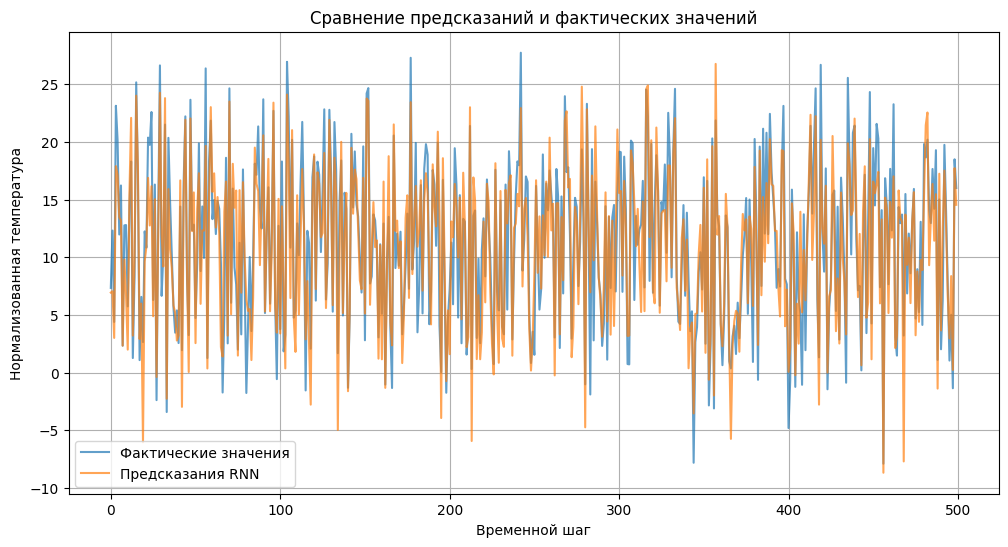

In [26]:
def make_predictions(model, generator, num_predictions=100):
    predictions = []
    actual_values = []
    
    for x, y in generator:
        pred = model.predict(x, verbose=0)
        predictions.extend(pred.flatten())
        actual_values.extend(y)
        num_predictions -= 1
        if num_predictions == 0:
            break
    predictions = [x * data_std[1] + data_mean[1] for x in predictions]
    actual_values = [x * data_std[1] + data_mean[1] for x in actual_values]
    return np.array(predictions), np.array(actual_values)

rnn_predictions, actual_values = make_predictions(model, test_generator)

plt.figure(figsize=(12, 6))
plt.plot(actual_values[:100], label='Фактические значения', alpha=0.7)
plt.plot(rnn_predictions[:100], label='Предсказания RNN', alpha=0.7)
plt.title('Сравнение предсказаний и фактических значений')
plt.xlabel('Временной шаг')
plt.ylabel('Нормализованная температура')
plt.legend()
plt.grid(True)
plt.show()

### Шаг 10: Сравнение со сверточной сетью

In [27]:
conv_model = Sequential([
    Conv1D(32, 5, activation='relu', input_shape=(sequence_length, train_data.shape[-1])),
    MaxPooling1D(3),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(3),
    Conv1D(128, 5, activation='relu'),
    MaxPooling1D(3),
    
    GRU(32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    GRU(64, dropout=0.2, recurrent_dropout=0.2),
    
    Dense(1)
])

conv_model.compile(optimizer='adam', loss='mae', metrics=['mae'])

conv_history = conv_model.fit(
    train_generator, steps_per_epoch=10, epochs=epochs, validation_data=val_generator, validation_steps=validation_steps
)

Epoch 1/40


/Users/krukrukruzhka/github_projects/ML_magister/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/var/folders/0g/zw0_s7w512zbvj6v01k842n00000gn/T/ipykernel_68109/1044423498.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  targets[i] = data.iloc[row + lookback + delay - 1][1]


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 332ms/step - loss: 0.5381 - mae: 0.5381 - val_loss: 0.4659 - val_mae: 0.4659
Epoch 2/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 312ms/step - loss: 0.4858 - mae: 0.4858 - val_loss: 0.4020 - val_mae: 0.4020
Epoch 3/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step - loss: 0.4577 - mae: 0.4577 - val_loss: 0.4108 - val_mae: 0.4108
Epoch 4/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - loss: 0.4498 - mae: 0.4498 - val_loss: 0.4326 - val_mae: 0.4326
Epoch 5/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 316ms/step - loss: 0.4579 - mae: 0.4579 - val_loss: 0.4238 - val_mae: 0.4238
Epoch 6/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 324ms/step - loss: 0.4413 - mae: 0.4413 - val_loss: 0.3861 - val_mae: 0.3861
Epoch 7/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step - loss: 0.3973 - mae: 0.3973 - val_loss: 0.3780 - val_mae: 0.3780
Epoch 8/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 323ms/step - loss: 0.4073 - mae: 0.4073 - val_loss: 0.3777 - val_mae: 0.3777
Epoch 9/40
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 327ms/step - loss: 0.4068 

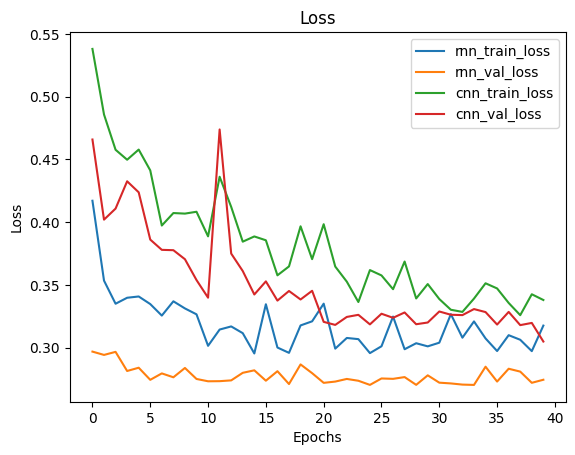

In [28]:
plt.plot(history.history['loss'], label='rnn_train_loss')
plt.plot(history.history['val_loss'], label='rnn_val_loss')
plt.plot(conv_history.history['loss'], label='cnn_train_loss')
plt.plot(conv_history.history['val_loss'], label='cnn_val_loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()